# Final Report

This notebook contains only the analyses selected for inclusion in the final report.


## Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

In [2]:
# Warm grey-and-teal report theme, based on the selected reference chart.
REPORT_BG = "#F4F1E8"
REPORT_INK = "#252421"
REPORT_MUTED = "#6F6C65"
REPORT_GRID = "#D8D3C8"
REPORT_GREY = "#77756F"
REPORT_LIGHT_GREY = "#AAA79F"
REPORT_TEAL = "#16876F"
REPORT_TEAL_MID = "#63B19E"
REPORT_TEAL_LIGHT = "#A7D2C7"

sns.set_theme(style="white")
plt.rcParams.update({
    "figure.facecolor": REPORT_BG,
    "axes.facecolor": REPORT_BG,
    "savefig.facecolor": REPORT_BG,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelcolor": REPORT_INK,
    "axes.titlecolor": REPORT_INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.color": REPORT_MUTED,
    "ytick.color": REPORT_MUTED,
    "text.color": REPORT_INK,
    "axes.edgecolor": REPORT_INK,
    "grid.color": REPORT_GRID,
    "grid.linewidth": 0.8,
    "figure.dpi": 115,
})

REPORT_CMAP = sns.light_palette(REPORT_TEAL, as_cmap=True)


def report_title(ax, title):
    # Apply the compact centered title used throughout the report.

    ax.set_title(
        title,
        loc="center",
        fontsize=13,
        fontweight="bold",
        color=REPORT_INK,
        pad=15,
    )


def report_axes(ax, grid_axis="x"):
    # Use dark baseline axes, a warm background, and quiet gridlines.

    ax.set_facecolor(REPORT_BG)
    ax.figure.patch.set_facecolor(REPORT_BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(REPORT_INK)
    ax.spines["bottom"].set_color(REPORT_INK)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)
    ax.tick_params(axis="both", colors=REPORT_MUTED, width=0.9)
    ax.grid(False)
    ax.grid(axis=grid_axis, color=REPORT_GRID, linewidth=0.8)
    ax.set_axisbelow(True)


def report_parity_line(ax):
    # Mark a ratio of one with a direct label rather than a legend.

    ax.axvline(
        1,
        color=REPORT_MUTED,
        linestyle=(0, (3, 2)),
        linewidth=1.1,
        zorder=3,
    )
    ax.annotate(
        "Parity = 1.0",
        xy=(1, 1),
        xycoords=("data", "axes fraction"),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.5,
        color=REPORT_MUTED,
        clip_on=False,
    )


def report_heatmap_text(ax, values):
    # Keep heatmap annotations legible on light and dark cells.

    maximum = float(np.nanmax(values.to_numpy()))
    threshold = maximum * 0.62
    for label, value in zip(ax.texts, values.to_numpy().ravel()):
        label.set_color("white" if value >= threshold else REPORT_INK)
        label.set_fontsize(8.5)


def highlight_bar_colors(values):
    # Highlight the two largest bars while keeping the rest neutral.

    values = pd.Series(values)
    colors = [REPORT_GREY] * len(values)
    if len(values) >= 2:
        second, first = values.nlargest(2).index[::-1]
        colors[second] = REPORT_TEAL_LIGHT
        colors[first] = REPORT_TEAL
    elif len(values) == 1:
        colors[0] = REPORT_TEAL
    return colors


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.precision", 1)

## Import the finalized survey data


In [3]:
data_path = Path("../1_data/2_clean/student_survey_cleaned.dta")

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path.resolve()}")

df = pd.read_stata(data_path)

print(f"Dataset loaded successfully: {df.shape[0]:,} respondents and {df.shape[1]} variables.")


Dataset loaded successfully: 836 respondents and 115 variables.


In [4]:
df.head()


,interview_date,interview_time,Interviewer_Name,Province,local_government,local_government_clean,lg_name,lg_type,lg_review,lg_review_note,ward,age,gender,education,edu_school,edu_plus2,edu_bachelors,edu_masters,ethnicity,religious_belief,religion,marital_status,life_place,family_abroad,family_returned,migration_plan,abroad_purpose,nepal_plan,q2_1,q2_2,q2_3,q2_4,q2_4_1,Others_Please_Specify,q2_5,q2_5_1,Others_please_specify_001,q2_6,q2_6_1,Others_please_specify_002,q2_7,q2_7_1,q2_8_1,q2_8_2,q2_8_3,q2_8_4,q2_8_5,q2_8_6,q2_9,q3_1_1,...,q3_9,q3_10_11,q3_10_11_001,q3_10_12,q3_10_13,q3_10_14,q3_10_15,q3_10_16,q3_10_17,q3_11_1,q3_11_2,q3_11_3,q3_11_4,q4_1,q4_2_1,q4_2_2,q4_2_3,q4_2_4,q4_2_5,q4_2_6,q4_2_7,q4_2_8,q4_3,q4_4,q4_5,q4_6,q4_7,q4_8,q5_1,q5_2_1,q5_2_2,q5_2_3,q5_2_4,q5_2_5,q5_2_6,q5_3,q5_4,q5_5,q5_6_1,q5_6_2,q5_6_3,q5_6_4,q5_6_5,q5_6_6,q5_6_7,q5_7_1,q5_7_2,q5_7_3,q5_7_4,age_cohort
0,2026-08-23,07:54:00.000+05:45,nabin,madhesh,Janakpur sub municipality,janakpur sub municipality,Janakpurdham,Municipality,0,,4.0,23,Female,Bachelors 2nd year,Private,Private,NaN,NaN,Madhesi,Yes,Hindu,Never Married,Urban,No,NaN,Stay in Nepal,NaN,Study Further,Disagree,Several times a week,No,Yes,,,Yes,,,Yes,,,Very Likely,NaN,No,No,No,No,Yes,No,Confident,Agree,...,Very Unlikely,Strongly Agree,Agree,Agree,Agree,Strongly Agree,Disagree,Agree,Agree,Neutral,Strongly Agree,Agree,Neutral,Somewhat Closely,Neutral,Neutral,Disagree,Disagree,Neutral,Disagree,Strongly Agree,Agree,Agree,Strongly Agree,Agree,Agree,Strongly Agree,Strongly Agree,Not Very Closely,Neutral,Agree,Neutral,Agree,Disagree,Agree,Neutral,Much more stable,Somewhat Optimistic,Agree,Neutral,Agree,Strongly Agree,Strongly Agree,Neutral,Agree,Strongly Agree,Agree,Agree,Strongly Agree,22–25
1,2026-08-23,08:47:00.000+05:45,nabin,madhesh,Janakpur sub municipality,janakpur sub municipality,Janakpurdham,Municipality,0,,4.0,21,Male,Bachelors 1st year,Private,Private,NaN,NaN,Madhesi,Yes,Hindu,Never Married,Urban,Yes,No,Go Abroad,Study and Work,NaN,Agree,Daily,Yes,NaN,,,NaN,,,NaN,,,Very Likely,NaN,No,No,No,Yes,No,No,Very Confident,Strongly Agree,...,Donot Know,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Agree,Agree,Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Very Closely,Agree,Strongly Agree,Strongly Agree,Neutral,Strongly Agree,Agree,Strongly Agree,Neutral,Strongly Agree,Agree,Neutral,Strongly Agree,Agree,Strongly Agree,Not Very Closely,Agree,Strongly Agree,Agree,Strongly Agree,Neutral,Strongly Agree,Strongly Agree,Somewhat more stable,Somewhat Optimistic,Strongly Agree,Agree,Strongly Agree,Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Agree,18–21
2,2026-08-23,09:17:00.000+05:45,nabin,madhesh,Janakpur sub municipality,janakpur sub municipality,Janakpurdham,Municipality,0,,4.0,20,Male,Bachelors 1st year,Public,Private,NaN,NaN,Madhesi,Yes,Hindu,Never Married,Urban,No,NaN,Go Abroad,Study and Work,NaN,Neutral,Weekly,Yes,NaN,,,NaN,,,NaN,,,Very Likely,NaN,No,No,Yes,Yes,Yes,No,Neutral,Agree,...,Somewhat Likely,Strongly Agree,Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Neutral,Strongly Agree,Strongly Agree,Very Closely,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Somewhat Closely,Strongly Agree,Agree,Agree,Agree,Strongly Agree,Agree,Strongly Agree,Somewhat more stable,Somewhat Optimistic,Agree,Agree,Agree,Strongly Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,18–21
3,2026-08-23,09:51:00.000+05:45,nabin,madhesh,Janakpur sub municipality,janakpur sub municipality,Janakpurdham,Municipality,0,,4.0,21,Male,Bachelors 1st year,Private,Private,NaN,NaN,Madhesi,Yes,Hindu,Never Married,Urban,No,NaN,Go Abroad,Study,NaN,Strongly Agree,Never,No,NaN,,,NaN,,,NaN,,,Very Likely,NaN,No,No,No,No,No,No,Confident,Strongly Agree,...,Very Unlikely,Strongly Agree,Stro

## Demographic profile

The following tables are the Python equivalent of Stata's one-way `tabulate` command. Percentages exclude missing observations.


In [5]:
# Correct the age-cohort labels that arrived with a text-encoding character.
if isinstance(df["age_cohort"].dtype, pd.CategoricalDtype):
    clean_age_labels = ["18–21", "22–25", "26–29", "30–35"]
    if len(df["age_cohort"].cat.categories) == len(clean_age_labels):
        df["age_cohort"] = df["age_cohort"].cat.rename_categories(
            clean_age_labels
        )


def stata_tabulate(data, variable, exclude_values=None):
    # Return a Stata-style one-way frequency table.

    series = data[variable]

    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        series = series.replace(r"^\s*$", pd.NA, regex=True)

    missing_n = int(series.isna().sum())
    excluded_n = 0

    if exclude_values:
        exclude_mask = series.astype("string").isin(exclude_values)
        excluded_n = int(exclude_mask.sum())
        series = series.mask(exclude_mask)

    valid = series.dropna()
    if isinstance(valid.dtype, pd.CategoricalDtype):
        valid = valid.cat.remove_unused_categories()
    counts = valid.value_counts(sort=False)

    table = counts.rename("Frequency").to_frame()
    table["Percent"] = table["Frequency"].div(len(valid)).mul(100)
    table["Cumulative percent"] = table["Percent"].cumsum()
    table.index.name = "Category"

    summary = f"Valid N = {len(valid):,}; missing = {missing_n:,}"
    if excluded_n:
        summary += f"; excluded = {excluded_n:,}"
    print(summary)

    return table.round({"Percent": 1, "Cumulative percent": 1})


def plot_frequency_bar(data, variable, title, exclude_values=None):
    # Plot valid-response percentages using the report theme.

    series = data[variable]

    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        series = series.replace(r"^\s*$", pd.NA, regex=True)

    if exclude_values:
        exclude_mask = series.astype("string").isin(exclude_values)
        series = series.mask(exclude_mask)

    valid = series.dropna()
    if isinstance(valid.dtype, pd.CategoricalDtype):
        valid = valid.cat.remove_unused_categories()
    percentages = valid.value_counts(sort=False, normalize=True).mul(100)

    figure_height = max(3.0, 0.46 * len(percentages) + 1.5)
    fig, ax = plt.subplots(figsize=(8.2, figure_height))
    bars = ax.barh(
        percentages.index.astype(str),
        percentages.values,
        color=highlight_bar_colors(percentages.values),
        height=0.72,
    )

    ax.bar_label(
        bars,
        labels=[f"{value:.1f}%" for value in percentages.values],
        padding=5,
        fontsize=9,
        color=REPORT_INK,
    )

    report_title(ax, title)
    report_axes(ax, grid_axis="x")
    ax.set_xlabel("Percent of valid responses")
    ax.set_ylabel("")
    ax.set_xlim(0, max(100, percentages.max() + 12))
    ax.invert_yaxis()

    plt.tight_layout(pad=1.2)
    plt.show()

### Age cohort


Valid N = 836; missing = 0


,Frequency,Percent,Cumulative percent
Category,,,
18–21,376,45.0,45.0
22–25,368,44.0,89.0
26–29,78,9.3,98.3
30–35,14,1.7,100.0


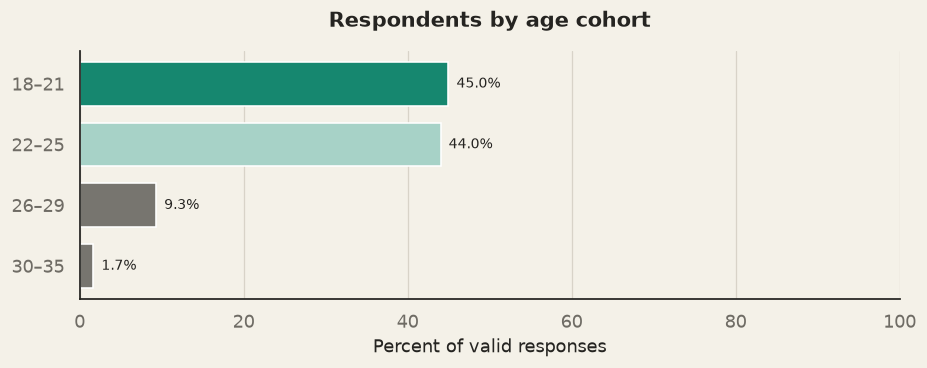

In [6]:
display(stata_tabulate(df, "age_cohort"))
plot_frequency_bar(df, "age_cohort", "Respondents by age cohort")


### Gender


Valid N = 836; missing = 0


,Frequency,Percent,Cumulative percent
Category,,,
Male,451,53.9,53.9
Female,385,46.1,100.0


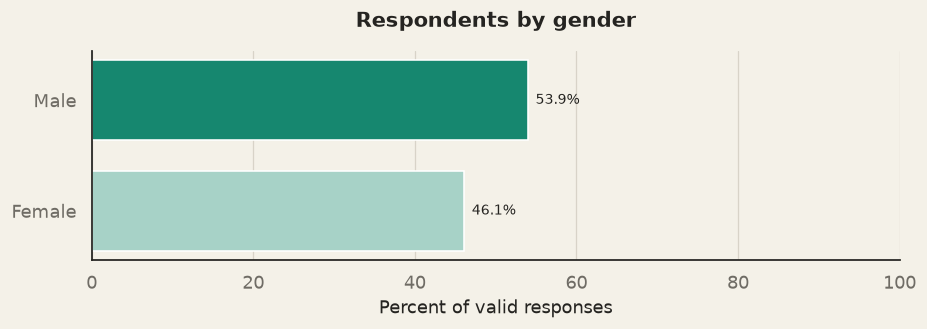

In [7]:
display(stata_tabulate(df, "gender"))
plot_frequency_bar(df, "gender", "Respondents by gender")


### Current education level and year


##### We have missing education institution type in masters' second year.
##### We also have missing education institution type for *ALL* current bachelors student.

Valid N = 836; missing = 0


,Frequency,Percent,Cumulative percent
Category,,,
Bachelors 1st year,155,18.5,18.5
Bachelors 2nd year,178,21.3,39.8
Bachelors 3rd year,212,25.4,65.2
Bachelors 4th year,182,21.8,87.0
Bachelors 5th year,16,1.9,88.9
Masters 1st year,63,7.5,96.4
Masters 2nd year,29,3.5,99.9
PHD,1,0.1,100.0


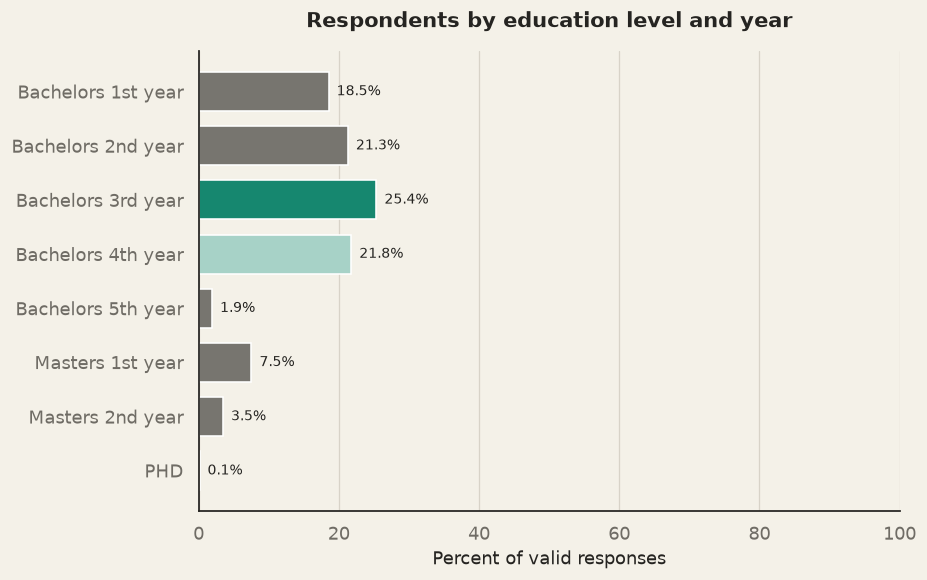

In [8]:
display(stata_tabulate(df, "education"))
plot_frequency_bar(df, "education", "Respondents by education level and year")


### Ethnicity


Valid N = 835; missing = 1


,Frequency,Percent,Cumulative percent
Category,,,
Bhramin/Chettri,354,42.4,42.4
Dalit,62,7.4,49.8
Janajati,154,18.4,68.3
Muslim,18,2.2,70.4
Madhesi,247,29.6,100.0


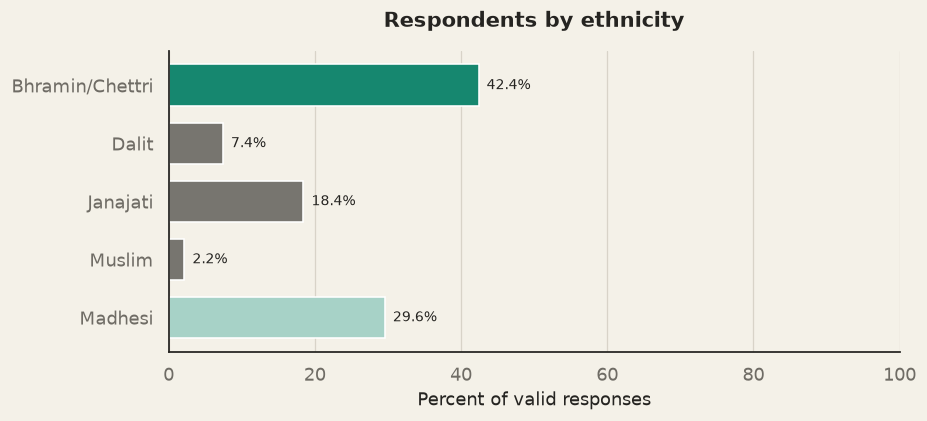

In [9]:
display(stata_tabulate(df, "ethnicity"))
plot_frequency_bar(df, "ethnicity", "Respondents by ethnicity")


### Religion

*The two respondents who selected “prefer not to say” are excluded from this table and graph.*


Valid N = 820; missing = 14; excluded = 2


,Frequency,Percent,Cumulative percent
Category,,,
Hindu,726,88.5,88.5
Muslim,21,2.6,91.1
Christian,29,3.5,94.6
Others,11,1.3,96.0
Buddhist,33,4.0,100.0


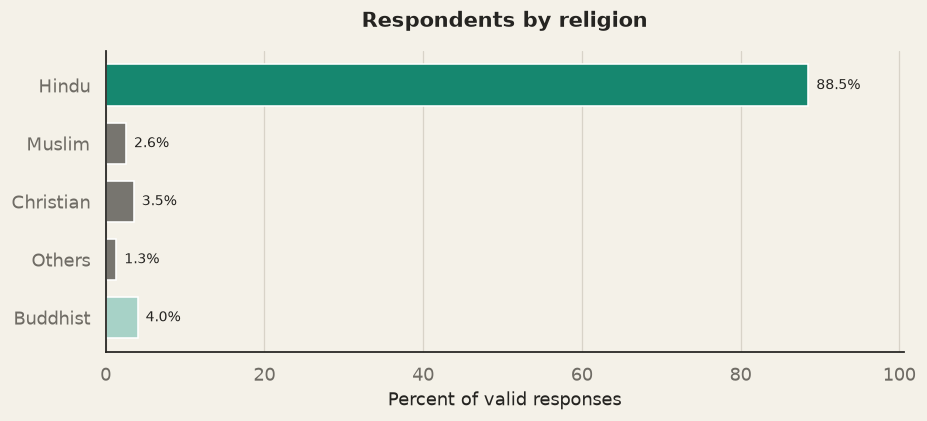

In [10]:
religion_exclusions = ["prefer_not_to_say"]

display(
    stata_tabulate(
        df,
        "religion",
        exclude_values=religion_exclusions,
    )
)

plot_frequency_bar(
    df,
    "religion",
    "Respondents by religion",
    exclude_values=religion_exclusions,
)


### Marital status


Valid N = 836; missing = 0


,Frequency,Percent,Cumulative percent
Category,,,
Never Married,776,92.8,92.8
Married,60,7.2,100.0


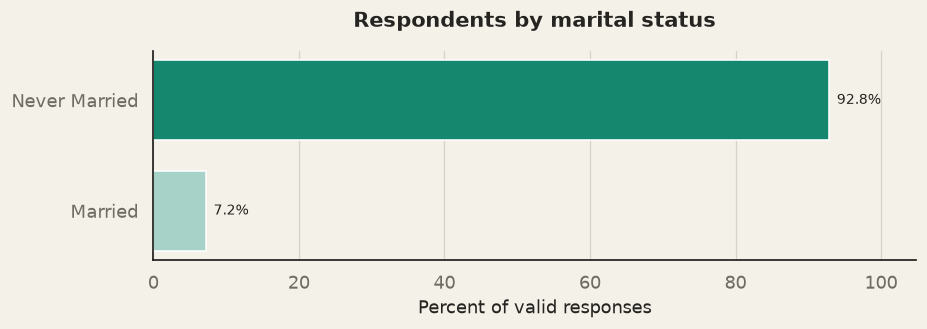

In [11]:
display(stata_tabulate(df, "marital_status"))
plot_frequency_bar(df, "marital_status", "Respondents by marital status")


### Urban/rural background


Valid N = 836; missing = 0


,Frequency,Percent,Cumulative percent
Category,,,
Urban,487,58.3,58.3
Rural,349,41.7,100.0


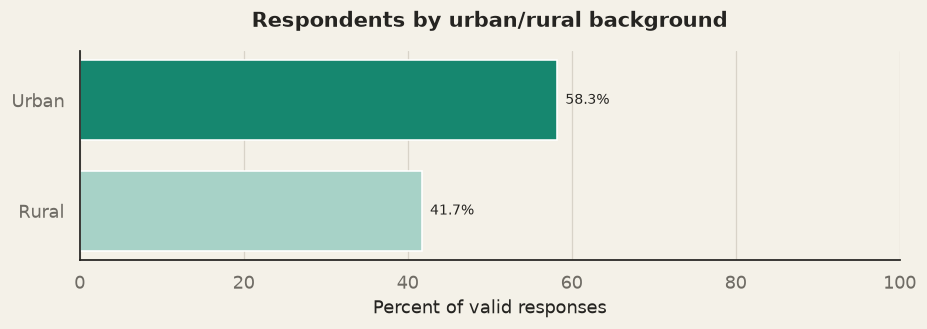

In [12]:
display(stata_tabulate(df, "life_place"))
plot_frequency_bar(df, "life_place", "Respondents by urban/rural background")


### Family migration experience

Whether a close family member has lived or currently lives abroad.


Valid N = 836; missing = 0


,Frequency,Percent,Cumulative percent
Category,,,
Yes,355,42.5,42.5
No,481,57.5,100.0


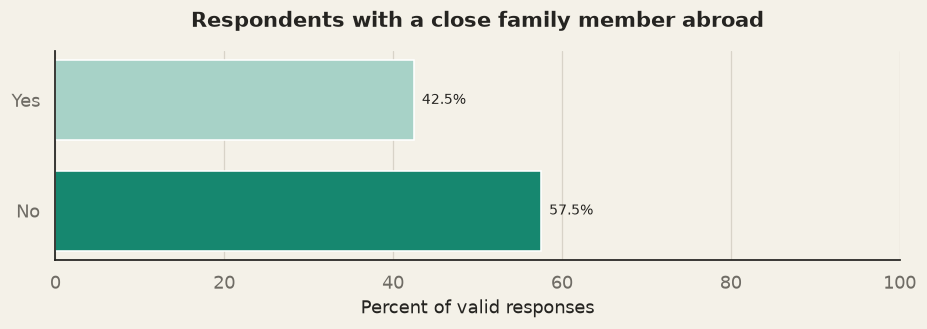

In [13]:
display(stata_tabulate(df, "family_abroad"))
plot_frequency_bar(
    df,
    "family_abroad",
    "Respondents with a close family member abroad",
)


## Educational institution background

The table reports the distribution of respondents across private and public institutions at each completed educational stage. Percentages are calculated across each row.

**Important:** The grand total is the number of institution-level responses across all four stages, not the number of unique respondents. Bachelor's and master's-or-higher questions apply only to respondents who had reached those stages.


In [14]:
institution_variables = {
    "SLC/SEE": "edu_school",
    "+2": "edu_plus2",
    "Bachelor's": "edu_bachelors",
    "Master's or higher": "edu_masters",
}

count_rows = []

for education_level, variable in institution_variables.items():
    valid = df[variable].dropna()
    private_n = int(valid.eq("Private").sum())
    public_n = int(valid.eq("Public").sum())

    count_rows.append({
        "Education level": education_level,
        "Private": private_n,
        "Public": public_n,
        "Total": private_n + public_n,
    })

institution_counts = pd.DataFrame(count_rows).set_index("Education level")
institution_counts.loc["Total"] = institution_counts.sum()

institution_percentages = (
    institution_counts
    .div(institution_counts["Total"], axis=0)
    .mul(100)
)

institution_table = institution_percentages.map(
    lambda value: f"{value + 1e-12:.2f}%"
)
institution_table.index.name = "Education level"
institution_table.columns.name = "Institution type"

institution_table


Institution type,Private,Public,Total
Education level,,,
SLC/SEE,51.38%,48.62%,100.00%
+2,58.20%,41.80%,100.00%
Bachelor's,20.43%,79.57%,100.00%
Master's or higher,15.63%,84.38%,100.00%
Total,51.67%,48.33%,100.00%


## Political attitudes and political-news consumption

The results are organized by survey question. For each question, the age-cohort and education results are presented together so that the same outcome can be compared across both demographic dimensions.

For the education analysis, **Bachelor's 4th year** and **Bachelor's 5th year** are combined into **Bachelor's final year**. The single **PhD** respondent is excluded because that category cannot support meaningful subgroup interpretation. These changes affect only an analysis-specific education variable; the original variable remains unchanged.

## Question 2.1: Politics is central to living in Nepal

For this analysis, **Prefer not to say** and any **Do not know** variants are included under **Neutral** in an analysis-specific response variable. The original `q2_1` variable remains unchanged.

### Tables by age cohort and education

In [15]:
q2_1_order = [
    "Strongly Agree", "Agree", "Neutral", "Disagree", "Strongly Disagree"
]

q2_1_text = df["q2_1"].astype("string").str.strip()
neutral_variants = {
    "prefer not to say", "do not know", "don't know", "dont know", "do_not_know"
}
q2_1_recode = q2_1_text.mask(
    q2_1_text.str.lower().isin(neutral_variants),
    "Neutral",
)

education_order = [
    "Bachelors 1st year",
    "Bachelors 2nd year",
    "Bachelors 3rd year",
    "Bachelors final year",
    "Masters 1st year",
    "Masters 2nd year",
]
education_analysis = (
    df["education"].astype("string").str.strip()
    .replace({
        "Bachelors 4th year": "Bachelors final year",
        "Bachelors 5th year": "Bachelors final year",
    })
)
education_analysis = education_analysis.mask(education_analysis.eq("PHD"))
education_analysis = pd.Categorical(
    education_analysis, categories=education_order, ordered=True
)


def grouped_response_summary(group, response, group_order, response_order, index_name):
    # Return counts, row percentages, and a report-ready combined table.
    counts = (
        pd.crosstab(group, response)
        .reindex(index=group_order, columns=response_order, fill_value=0)
    )
    percentages = counts.div(counts.sum(axis=1), axis=0).mul(100)
    table = counts.astype(int).astype(str) + " (" + percentages.map(
        lambda value: f"{value:.1f}%"
    ) + ")"
    table["Total n"] = counts.sum(axis=1).astype(int)
    table.index.name = index_name
    table.columns.name = "Response: n (row %)"
    return counts, percentages, table


age_order = list(df["age_cohort"].cat.categories)
age_q2_1_counts, age_q2_1_pct, age_q2_1_table = grouped_response_summary(
    df["age_cohort"], q2_1_recode, age_order, q2_1_order, "Age cohort"
)
education_q2_1_counts, education_q2_1_pct, education_q2_1_table = (
    grouped_response_summary(
        education_analysis,
        q2_1_recode,
        education_order,
        q2_1_order,
        "Education level and year",
    )
)

display(HTML("<h4>Age cohort</h4>"))
display(age_q2_1_table)
display(HTML("<h4>Education level and year</h4>"))
display(education_q2_1_table)

Response: n (row %),Strongly Agree,Agree,Neutral,Disagree,Strongly Disagree,Total n
Age cohort,,,,,,
18–21,31 (8.2%),94 (25.0%),76 (20.2%),98 (26.1%),77 (20.5%),376
22–25,40 (10.9%),116 (31.5%),67 (18.2%),89 (24.2%),56 (15.2%),368
26–29,13 (16.7%),19 (24.4%),16 (20.5%),18 (23.1%),12 (15.4%),78
30–35,2 (14.3%),5 (35.7%),1 (7.1%),5 (35.7%),1 (7.1%),14


Response: n (row %),Strongly Agree,Agree,Neutral,Disagree,Strongly Disagree,Total n
Education level and year,,,,,,
Bachelors 1st year,16 (10.3%),42 (27.1%),39 (25.2%),33 (21.3%),25 (16.1%),155
Bachelors 2nd year,19 (10.7%),48 (27.0%),33 (18.5%),41 (23.0%),37 (20.8%),178
Bachelors 3rd year,19 (9.0%),58 (27.4%),32 (15.1%),63 (29.7%),40 (18.9%),212
Bachelors final year,21 (10.6%),61 (30.8%),38 (19.2%),49 (24.7%),29 (14.6%),198
Masters 1st year,5 (7.9%),17 (27.0%),13 (20.6%),18 (28.6%),10 (15.9%),63
Masters 2nd year,6 (20.7%),8 (27.6%),5 (17.2%),5 (17.2%),5 (17.2%),29


#### Interpretation of the Question 2.1 tables

Among respondents aged **18–21**, 33.2% agree or strongly agree that politics is central to living in Nepal, compared with 46.6% who disagree or strongly disagree. The 22–25 and 26–29 cohorts are much closer to balance. The 30–35 cohort leans slightly toward agreement, but it contains only 14 respondents and should not be generalized.

The education results are also mixed. Bachelor's third-year respondents have the largest combined disagreement share (**48.6%**). The combined bachelor's final-year group is nearly balanced, with 82 respondents agreeing and 78 disagreeing. Master's second year has the highest combined agreement share (**48.3%**), but this subgroup contains only 29 respondents.

### Heatmaps by age cohort and education

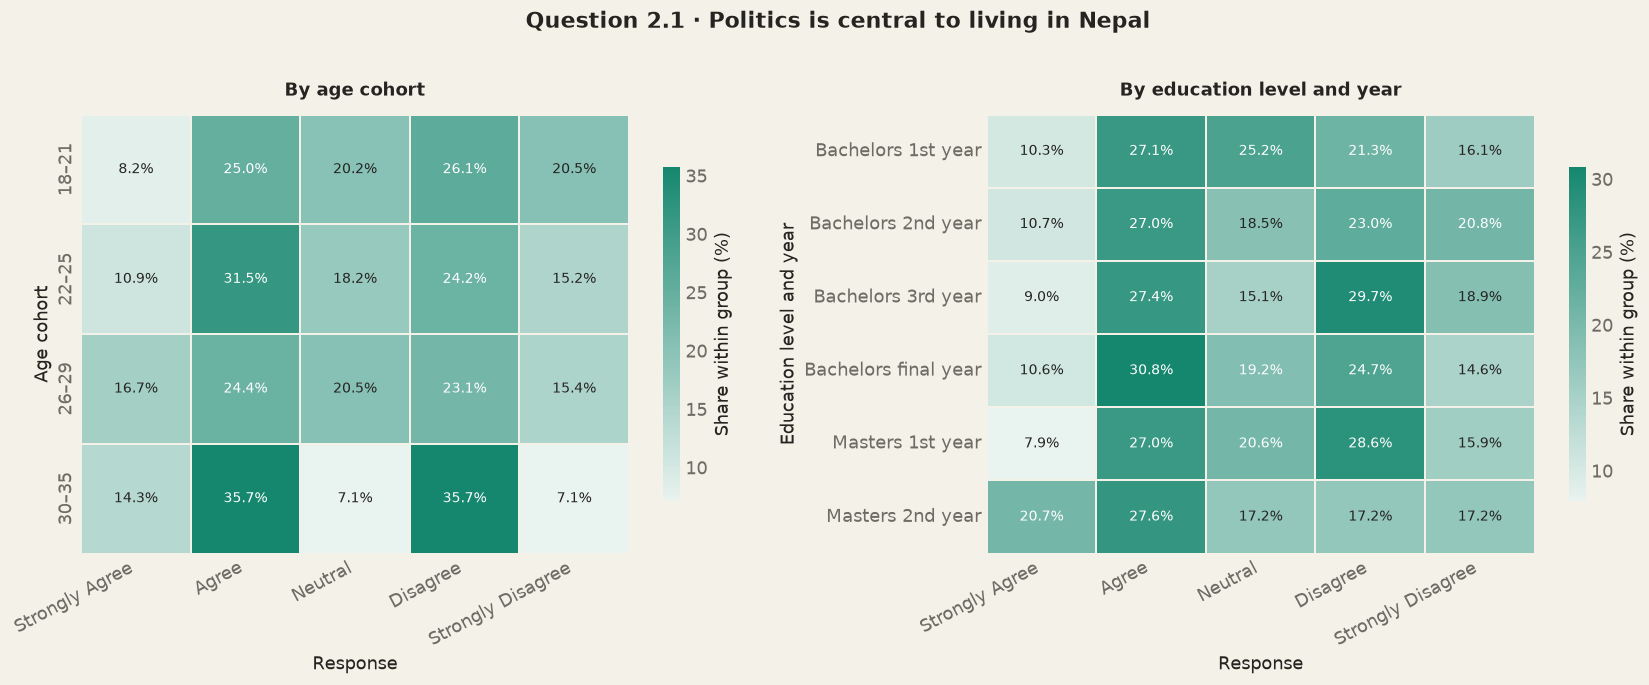

In [16]:
def draw_response_heatmap(ax, percentages, title, y_label, x_rotation=25):
    labels = percentages.map(lambda value: f"{value:.1f}%")
    heatmap = sns.heatmap(
        percentages,
        annot=labels,
        fmt="",
        cmap=REPORT_CMAP,
        linewidths=1.0,
        linecolor=REPORT_BG,
        cbar_kws={"label": "Share within group (%)", "shrink": 0.76},
        ax=ax,
    )
    ax.set_title(title, fontsize=11.5, fontweight="bold", pad=12)
    ax.set_xlabel("Response")
    ax.set_ylabel(y_label)
    ax.tick_params(axis="both", length=0, colors=REPORT_MUTED)
    ax.tick_params(axis="x", rotation=x_rotation)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    heatmap.collections[0].colorbar.outline.set_visible(False)
    heatmap.collections[0].colorbar.ax.tick_params(length=0, colors=REPORT_MUTED)
    report_heatmap_text(ax, percentages)


fig, axes = plt.subplots(1, 2, figsize=(14.8, 5.8))
fig.suptitle(
    "Question 2.1 · Politics is central to living in Nepal",
    fontsize=14,
    fontweight="bold",
    color=REPORT_INK,
    y=1.02,
)
draw_response_heatmap(
    axes[0], age_q2_1_pct, "By age cohort", "Age cohort", x_rotation=28
)
draw_response_heatmap(
    axes[1],
    education_q2_1_pct,
    "By education level and year",
    "Education level and year",
    x_rotation=28,
)
plt.tight_layout(pad=1.1, w_pad=2.0)
plt.show()

#### Interpretation of the Question 2.1 heatmaps

The heatmaps reinforce the absence of a simple demographic progression. By age, the youngest cohort is the most disagreement-oriented, while the middle cohorts are closer to balance. By education, bachelor's third year stands out for relatively high disagreement, whereas the combined bachelor's final year and master's second year lean somewhat more toward agreement. Neither dimension displays a consistent linear pattern.

### Agreement-to-disagreement ratios by age cohort and education

The ratio divides combined agreement (**Strongly Agree + Agree**) by combined disagreement (**Disagree + Strongly Disagree**). Neutral responses are excluded from both parts. Values above 1 indicate more agreement; values below 1 indicate more disagreement.

,Agree n,Disagree n,Agree/disagree ratio,Direction
Age cohort,,,,
18–21,125,175,0.71,More disagreement
22–25,156,145,1.08,More agreement
26–29,32,30,1.07,More agreement
30–35,7,6,1.17,More agreement


,Agree n,Disagree n,Agree/disagree ratio,Direction
Education level and year,,,,
Bachelors 1st year,58,58,1.00,Equal
Bachelors 2nd year,67,78,0.86,More disagreement
Bachelors 3rd year,77,103,0.75,More disagreement
Bachelors final year,82,78,1.05,More agreement
Masters 1st year,22,28,0.79,More disagreement
Masters 2nd year,14,10,1.40,More agreement


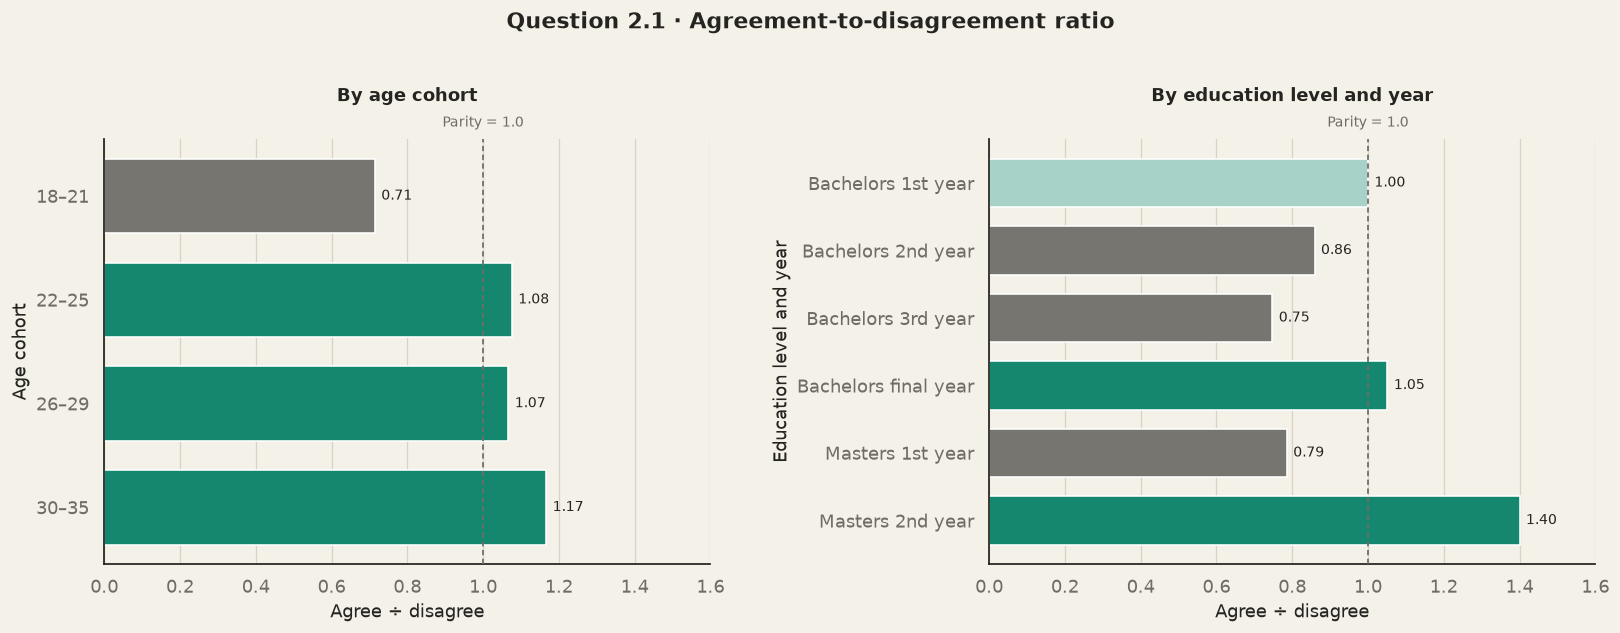

In [17]:
def build_agreement_ratio(counts):
    agree = counts[["Strongly Agree", "Agree"]].sum(axis=1)
    disagree = counts[["Disagree", "Strongly Disagree"]].sum(axis=1)
    ratio = agree.div(disagree.replace(0, np.nan))
    table = pd.DataFrame({
        "Agree n": agree.astype(int),
        "Disagree n": disagree.astype(int),
        "Agree/disagree ratio": ratio.map(lambda value: f"{value:.2f}"),
        "Direction": np.select(
            [ratio > 1, ratio < 1],
            ["More agreement", "More disagreement"],
            default="Equal",
        ),
    })
    return ratio, table


def draw_agreement_ratio(ax, ratios, title, x_limit):
    colors = [
        REPORT_TEAL if value > 1
        else REPORT_TEAL_LIGHT if value == 1
        else REPORT_GREY
        for value in ratios
    ]
    bars = ax.barh(
        ratios.index.astype(str),
        ratios.values,
        color=colors,
        height=0.72,
        zorder=2,
    )
    ax.bar_label(
        bars,
        labels=[f"{value:.2f}" for value in ratios],
        padding=4,
        fontsize=8.5,
        color=REPORT_INK,
    )
    report_parity_line(ax)
    report_axes(ax, grid_axis="x")
    ax.set_title(title, fontsize=11.5, fontweight="bold", pad=24)
    ax.set_xlabel("Agree ÷ disagree")
    ax.set_ylabel("")
    ax.set_xlim(0, x_limit)
    ax.invert_yaxis()


age_agreement_ratio, age_agreement_table = build_agreement_ratio(
    age_q2_1_counts
)
education_agreement_ratio, education_agreement_table = build_agreement_ratio(
    education_q2_1_counts
)
age_agreement_table.index.name = "Age cohort"
education_agreement_table.index.name = "Education level and year"

display(HTML("<h4>Age cohort</h4>"))
display(age_agreement_table)
display(HTML("<h4>Education level and year</h4>"))
display(education_agreement_table)

shared_ratio_limit = max(
    1.6,
    age_agreement_ratio.max() + 0.2,
    education_agreement_ratio.max() + 0.2,
)
fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.3))
fig.suptitle(
    "Question 2.1 · Agreement-to-disagreement ratio",
    fontsize=14,
    fontweight="bold",
    color=REPORT_INK,
    y=1.03,
)
draw_agreement_ratio(
    axes[0], age_agreement_ratio, "By age cohort", shared_ratio_limit
)
draw_agreement_ratio(
    axes[1], education_agreement_ratio, "By education level and year", shared_ratio_limit
)
axes[0].set_ylabel("Age cohort")
axes[1].set_ylabel("Education level and year")
plt.tight_layout(pad=1.1, w_pad=3.0)
plt.show()

#### Interpretation of the Question 2.1 ratios

By age, respondents aged 18–21 lean toward disagreement (**0.71**). The 22–25 (**1.08**), 26–29 (**1.07**), and 30–35 (**1.17**) cohorts are close to balance or lean slightly toward agreement, although the oldest cohort is very small.

By education, bachelor's first year is exactly balanced (**1.00**). Bachelor's second year (**0.86**), bachelor's third year (**0.75**), and master's first year (**0.79**) lean toward disagreement. The combined bachelor's final year is close to balance but leans slightly toward agreement (**1.05**), while master's second year has the highest ratio (**1.40**). Overall, the education pattern is mixed rather than monotonic.

## Question 2.2: Frequency of following political news

The original response categories are retained: Daily, Several times a week, Weekly, Occasionally, and Never.

### Tables by age cohort and education

In [18]:
q2_2_order = [
    "Daily", "Several times a week", "Weekly", "Occasionally", "Never"
]
q2_2_recode = df["q2_2"].astype("string").str.strip()

age_q2_2_counts, age_q2_2_pct, age_q2_2_table = grouped_response_summary(
    df["age_cohort"], q2_2_recode, age_order, q2_2_order, "Age cohort"
)
education_q2_2_counts, education_q2_2_pct, education_q2_2_table = (
    grouped_response_summary(
        education_analysis,
        q2_2_recode,
        education_order,
        q2_2_order,
        "Education level and year",
    )
)

display(HTML("<h4>Age cohort</h4>"))
display(age_q2_2_table)
display(HTML("<h4>Education level and year</h4>"))
display(education_q2_2_table)

Response: n (row %),Daily,Several times a week,Weekly,Occasionally,Never,Total n
Age cohort,,,,,,
18–21,164 (43.6%),100 (26.6%),20 (5.3%),83 (22.1%),9 (2.4%),376
22–25,206 (56.0%),103 (28.0%),7 (1.9%),48 (13.0%),4 (1.1%),368
26–29,64 (82.1%),6 (7.7%),3 (3.8%),5 (6.4%),0 (0.0%),78
30–35,12 (85.7%),2 (14.3%),0 (0.0%),0 (0.0%),0 (0.0%),14


Response: n (row %),Daily,Several times a week,Weekly,Occasionally,Never,Total n
Education level and year,,,,,,
Bachelors 1st year,61 (39.4%),39 (25.2%),12 (7.7%),38 (24.5%),5 (3.2%),155
Bachelors 2nd year,77 (43.3%),55 (30.9%),6 (3.4%),36 (20.2%),4 (2.2%),178
Bachelors 3rd year,114 (53.8%),58 (27.4%),7 (3.3%),31 (14.6%),2 (0.9%),212
Bachelors final year,123 (62.1%),45 (22.7%),1 (0.5%),27 (13.6%),2 (1.0%),198
Masters 1st year,43 (68.3%),12 (19.0%),4 (6.3%),4 (6.3%),0 (0.0%),63
Masters 2nd year,27 (93.1%),2 (6.9%),0 (0.0%),0 (0.0%),0 (0.0%),29


#### Interpretation of the Question 2.2 tables

Political-news consumption increases clearly with age. Daily following rises from **43.6%** among respondents aged 18–21 to **56.0%** among ages 22–25 and **82.1%** among ages 26–29. Twelve of the 14 respondents aged 30–35 follow political news daily, although that subgroup is too small for broad generalization.

A similar pattern appears across education groups. Daily news-following rises from **39.4%** in bachelor's first year to **62.1%** in the combined bachelor's final year and **68.3%** in master's first year. It reaches **93.1%** among master's second-year respondents, but that estimate is based on only 29 respondents.

### Heatmaps by age cohort and education

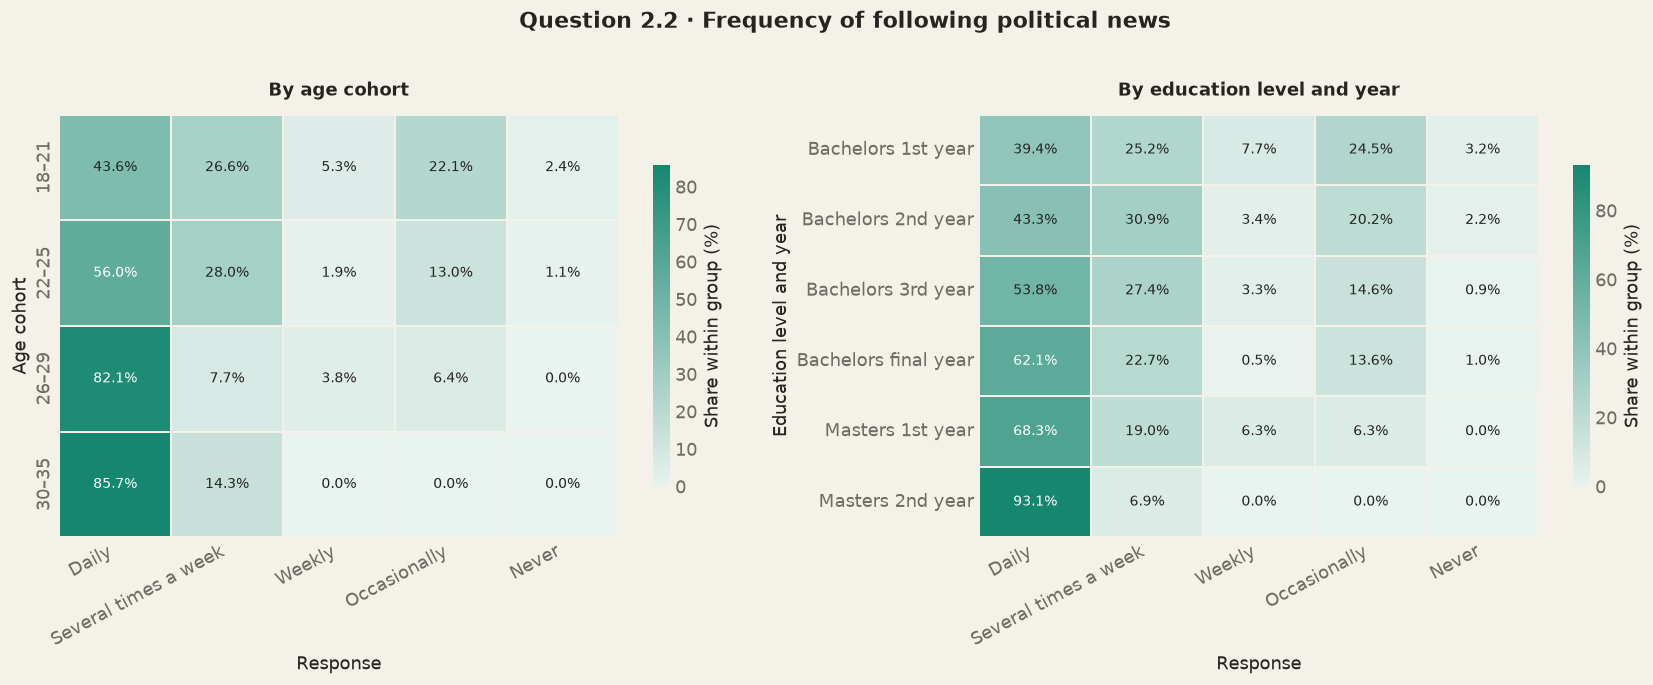

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14.8, 5.8))
fig.suptitle(
    "Question 2.2 · Frequency of following political news",
    fontsize=14,
    fontweight="bold",
    color=REPORT_INK,
    y=1.02,
)
draw_response_heatmap(
    axes[0], age_q2_2_pct, "By age cohort", "Age cohort", x_rotation=28
)
draw_response_heatmap(
    axes[1],
    education_q2_2_pct,
    "By education level and year",
    "Education level and year",
    x_rotation=28,
)
plt.tight_layout(pad=1.1, w_pad=2.0)
plt.show()

#### Interpretation of the Question 2.2 heatmaps

Both heatmaps show a clearer gradient than Question 2.1. Daily political-news consumption becomes increasingly dominant among older respondents and among respondents in later education groups. Occasional or no news-following is concentrated most heavily among ages 18–21 and bachelor's first-year students. The very high daily shares in ages 30–35 and master's second year should still be interpreted cautiously because those groups contain only 14 and 29 respondents, respectively.

## Ordered-probit analysis

This section reproduces the ordered-probit analysis specified in `analysis.do` using Python. The five-category outcome is coded from **1 = Strongly disagree** to **5 = Strongly agree**, so a positive coefficient indicates a greater tendency toward stronger agreement that politics is central to living in Nepal. **Prefer not to say** remains missing for this model.

The main news variable follows the Stata specification exactly: **Daily** and **Several times a week** are coded as frequent, while **Weekly**, **Occasionally**, and **Never** form the reference category. All seven models use the same complete-case estimation sample and report conventional model-based standard errors.

Every model controls for gender, age, education stage, ethnicity, broad religion, and province. The reference categories are male, urban upbringing, public education at both SLC/SEE and +2, no family member abroad, bachelor's years 1–2, Brahmin/Chettri, Hindu, and Bagamati Province.

In [20]:
from statsmodels.miscmodels.ordinal_model import OrderedModel


# Construct the same analysis variables used in the Stata file.
model_data = pd.DataFrame(index=df.index)
model_data["politics5"] = df["q2_1"].astype("string").map({
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5,
})
model_data["politics3"] = df["q2_1"].astype("string").map({
    "Strongly Disagree": 1,
    "Disagree": 1,
    "Neutral": 2,
    "Agree": 3,
    "Strongly Agree": 3,
})
model_data["rural"] = df["life_place"].astype("string").map({
    "Urban": 0, "Rural": 1
})
model_data["female"] = df["gender"].astype("string").map({
    "Male": 0, "Female": 1
})
model_data["family_abroad"] = df["family_abroad"].astype("string").map({
    "No": 0, "Yes": 1
})
model_data["news_frequent"] = df["q2_2"].astype("string").map({
    "Daily": 1,
    "Several times a week": 1,
    "Weekly": 0,
    "Occasionally": 0,
    "Never": 0,
})

school = df["edu_school"].astype("string")
plus2 = df["edu_plus2"].astype("string")
model_data["school_path"] = pd.NA
model_data.loc[
    school.eq("Public") & plus2.eq("Public"), "school_path"
] = "Public at both stages"
model_data.loc[
    school.ne(plus2) & school.notna() & plus2.notna(), "school_path"
] = "Mixed public/private"
model_data.loc[
    school.eq("Private") & plus2.eq("Private"), "school_path"
] = "Private at both stages"

education = df["education"].astype("string")
model_data["education_stage"] = pd.NA
model_data.loc[
    education.isin(["Bachelors 1st year", "Bachelors 2nd year"]),
    "education_stage",
] = "Bachelors years 1-2"
model_data.loc[
    education.isin([
        "Bachelors 3rd year", "Bachelors 4th year", "Bachelors 5th year"
    ]),
    "education_stage",
] = "Bachelors years 3-5"
model_data.loc[
    education.isin(["Masters 1st year", "Masters 2nd year", "PHD"]),
    "education_stage",
] = "Masters or PhD"

religion = df["religion"].astype("string")
belief = df["religious_belief"].astype("string")
model_data["religion3"] = pd.NA
model_data.loc[religion.eq("Hindu"), "religion3"] = "Hindu"
model_data.loc[
    religion.isin(["Muslim", "Christian", "Others", "Buddhist"]),
    "religion3",
] = "Other religion"
model_data.loc[
    belief.isin(["No", "Not Sure"]), "religion3"
] = "No or uncertain religious belief"

model_data["age"] = df["age"]
model_data["ethnicity"] = df["ethnicity"].astype("string")
model_data["province"] = df["Province"].astype("string")
required_variables = [
    "politics5", "rural", "school_path", "news_frequent",
    "family_abroad", "female", "age", "education_stage",
    "ethnicity", "religion3", "province",
]
estimation_data = model_data.dropna(subset=required_variables).copy()


def reference_dummies(series, categories, reference, prefix):
    categorical = pd.Categorical(series, categories=categories)
    result = pd.get_dummies(categorical, prefix=prefix, dtype=float)
    result.index = series.index
    return result.drop(columns=[f"{prefix}_{reference}"])


controls = pd.concat([
    estimation_data[["female", "age"]].astype(float),
    reference_dummies(
        estimation_data["education_stage"],
        ["Bachelors years 1-2", "Bachelors years 3-5", "Masters or PhD"],
        "Bachelors years 1-2",
        "education",
    ),
    reference_dummies(
        estimation_data["ethnicity"],
        ["Bhramin/Chettri", "Dalit", "Janajati", "Muslim", "Madhesi"],
        "Bhramin/Chettri",
        "ethnicity",
    ),
    reference_dummies(
        estimation_data["religion3"],
        ["Hindu", "Other religion", "No or uncertain religious belief"],
        "Hindu",
        "religion",
    ),
    reference_dummies(
        estimation_data["province"],
        [
            "bagamati", "gandaki", "karnali", "koshi",
            "lumbini", "madhesh", "sudurpaschim",
        ],
        "bagamati",
        "province",
    ),
], axis=1)

school_path_dummies = reference_dummies(
    estimation_data["school_path"],
    ["Public at both stages", "Mixed public/private", "Private at both stages"],
    "Public at both stages",
    "school",
)
focal_variables = estimation_data[
    ["rural", "news_frequent", "family_abroad"]
].astype(float)

model_matrices = {
    "(1) Rural": pd.concat([focal_variables[["rural"]], controls], axis=1),
    "(2) School path": pd.concat([school_path_dummies, controls], axis=1),
    "(3) News": pd.concat([focal_variables[["news_frequent"]], controls], axis=1),
    "(4) Family abroad": pd.concat([focal_variables[["family_abroad"]], controls], axis=1),
    "(5) Background": pd.concat([
        focal_variables[["rural", "family_abroad"]],
        school_path_dummies,
        controls,
    ], axis=1),
    "(6) Full": pd.concat([
        focal_variables,
        school_path_dummies,
        controls,
    ], axis=1),
    "(7) Three-category": pd.concat([
        focal_variables,
        school_path_dummies,
        controls,
    ], axis=1),
}

ordered_results = {}
for model_name, design_matrix in model_matrices.items():
    outcome = "politics3" if model_name.startswith("(7)") else "politics5"
    ordered_model = OrderedModel(
        estimation_data[outcome].astype(int),
        design_matrix,
        distr="probit",
    )
    ordered_results[model_name] = ordered_model.fit(
        method="bfgs",
        disp=False,
    )

model_check = pd.DataFrame({
    "Observations": [len(estimation_data)],
    "Standard errors": ["Model-based"],
    "All models converged": [all(
        result.mle_retvals.get("converged", False)
        for result in ordered_results.values()
    )],
})
display(model_check)

,Observations,Standard errors,All models converged
0,816,Model-based,True


### Ordered-probit results

The table reports ordered-probit coefficients, with conventional model-based standard errors in parentheses. Cut points are estimated but omitted from the report table. Significance markers are: *** p < 0.01, ** p < 0.05, and * p < 0.10.

In [21]:
model_columns = list(ordered_results)
focal_terms = [
    ("news_frequent", "Frequently follows political news"),
    ("rural", "Rural upbringing"),
    ("school_Mixed public/private", "Mixed public/private education"),
    ("school_Private at both stages", "Private education at both stages"),
    ("family_abroad", "Close family member has lived abroad"),
]


def significance_stars(p_value):
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""


report_rows = {}
for parameter, label in focal_terms:
    cells = []
    for model_name in model_columns:
        result = ordered_results[model_name]
        if parameter in result.params.index:
            coefficient = result.params[parameter]
            standard_error = result.bse[parameter]
            stars = significance_stars(result.pvalues[parameter])
            cells.append(f"{coefficient:.3f}{stars}\n({standard_error:.3f})")
        else:
            cells.append("—")
    report_rows[label] = cells

report_rows["Demographic controls"] = ["Yes"] * len(model_columns)
report_rows["Outcome categories"] = ["5"] * 6 + ["3"]
report_rows["Observations"] = [f"{len(estimation_data):,}"] * len(model_columns)
report_rows["Log likelihood"] = [
    f"{ordered_results[name].llf:.1f}" for name in model_columns
]
report_rows["AIC"] = [
    f"{ordered_results[name].aic:.1f}" for name in model_columns
]

ordered_probit_table = pd.DataFrame.from_dict(
    report_rows,
    orient="index",
    columns=model_columns,
)
ordered_probit_table.index.name = "Predictor / model statistic"

header_html = "".join(
    f"<th>{column}</th>" for column in ordered_probit_table.columns
)
body_rows = []
for row_label, row in ordered_probit_table.iterrows():
    value_cells = "".join(
        f"<td>{'<br>'.join(str(value).splitlines())}</td>"
        for value in row
    )
    body_rows.append(f"<tr><th>{row_label}</th>{value_cells}</tr>")
body_html = "".join(body_rows)

table_html = (
    '<div id="ordered-probit-report" style="overflow-x:auto; margin:8px 0 14px 0;">'
    '<table style="border-collapse:collapse; min-width:1080px; '
    'font-family:DejaVu Sans, sans-serif; font-size:12px;">'
    '<caption style="caption-side:top; text-align:left; font-size:15px; '
    'font-weight:700; color:#252421; padding:0 0 10px 0;">'
    'Ordered-probit models of agreement that politics is central to living in Nepal'
    '</caption>'
    '<thead><tr><th style="text-align:left;">Predictor / model statistic</th>'
    f'{header_html}</tr></thead>'
    f'<tbody>{body_html}</tbody></table>'
    '<style>'
    '#ordered-probit-report thead th {background:#16876F; color:white; font-weight:600; '
    'padding:7px 8px; border:1px solid #F4F1E8; text-align:center;}'
    '#ordered-probit-report tbody th {background:#F4F1E8; color:#252421; text-align:left; '
    'padding:7px 8px; border-bottom:1px solid #D8D3C8;}'
    '#ordered-probit-report tbody td {background:#F4F1E8; color:#252421; text-align:center; '
    'padding:7px 8px; border-bottom:1px solid #D8D3C8;}'
    '</style></div>'
)
display(HTML(table_html))

Predictor / model statistic,(1) Rural,(2) School path,(3) News,(4) Family abroad,(5) Background,(6) Full,(7) Three-category
Frequently follows political news,—,—,0.233**(0.098),—,—,0.242**(0.100),0.281**(0.111)
Rural upbringing,0.109(0.077),—,—,—,0.128(0.086),0.142*(0.086),0.079(0.097)
Mixed public/private education,—,-0.017(0.103),—,—,0.016(0.105),0.040(0.106),0.047(0.119)
Private education at both stages,—,-0.021(0.090),—,—,0.046(0.101),0.071(0.102),0.062(0.114)
Close family member has lived abroad,—,—,—,-0.037(0.077),-0.039(0.077),-0.018(0.078),0.001(0.087)
Demographic controls,Yes,Yes,Yes,Yes,Yes,Yes,Yes
Outcome categories,5,5,5,5,5,5,3
Observations,816,816,816,816,816,816,816
Log likelihood,-1236.0,-1237.0,-1234.2,-1236.9,-1235.8,-1232.8,-815.6
AIC,2514.0,2518.0,2510.4,2515.8,2519.6,2515.6,1677.2


### Interpretation

After removing municipality–ward clustering, the complete-case sample increases to **816 respondents** because ward information is no longer required. Frequent political-news consumption is positively associated with stronger agreement that politics is central to living in Nepal. Its coefficient is **0.233** in the predictor-specific model and **0.242** in the fully adjusted model; both are statistically significant at the 5% level. The three-category robustness model produces a similar positive coefficient of **0.281**, also significant at the 5% level.

Rural upbringing is positive in every specification and reaches the 10% significance threshold only in the fully adjusted five-category model (**0.142**). The educational-sector trajectory and family-migration variables remain statistically inconclusive across the models.

These results use conventional model-based standard errors. The coefficients describe shifts in an unobserved tendency toward stronger agreement; they are not percentage-point changes or predicted probabilities. The findings are associational, not causal, and should be interpreted alongside the descriptive patterns reported above.